# Shopper Spectrum

## Customer Segmentation and Product Recommendation in E-Commerce

### Objective

To analyze customer purchase behavior using RFM Analysis, segment customers using K-Means Clustering, and build a product recommendation system using Collaborative Filtering.

In [6]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# Save Models
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# ==========================================
# Load the Dataset
# ==========================================

df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


In [8]:
# Display first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
print("Dataset Shape:", df.shape)

Dataset Shape: (541909, 8)


In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [12]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 5268


In [15]:
# ==========================================
# Create a Copy of Dataset
# ==========================================

df_clean = df.copy()

print("Dataset copied successfully!")

Dataset copied successfully!


In [16]:
# ==========================================
# Convert InvoiceDate to Datetime
# ==========================================

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print(df_clean["InvoiceDate"].dtype)

datetime64[us]


In [17]:
# ==========================================
# Remove Missing CustomerID
# ==========================================

df_clean = df_clean.dropna(subset=["CustomerID"])

print("Shape after removing missing CustomerID:", df_clean.shape)

Shape after removing missing CustomerID: (406829, 8)


In [18]:
# ==========================================
# Remove Duplicate Records
# ==========================================

df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (401604, 8)


In [19]:
# ==========================================
# Remove Cancelled Orders
# ==========================================

df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

print("Shape after removing cancelled orders:", df_clean.shape)

Shape after removing cancelled orders: (392732, 8)


In [20]:
# ==========================================
# Remove Invalid Quantity
# ==========================================

df_clean = df_clean[df_clean["Quantity"] > 0]

print("Shape after removing invalid quantity:", df_clean.shape)

Shape after removing invalid quantity: (392732, 8)


In [21]:
# ==========================================
# Remove Invalid Prices
# ==========================================

df_clean = df_clean[df_clean["UnitPrice"] > 0]

print("Shape after removing invalid prices:", df_clean.shape)

Shape after removing invalid prices: (392692, 8)


In [22]:
# ==========================================
# Create Total Amount
# ==========================================

df_clean["TotalAmount"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [23]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 49.2 MB


In [24]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

# Exploratory Data Analysis (EDA)

## Business Overview

In [25]:
# ==========================================
# Business KPIs
# ==========================================

total_revenue = df_clean["TotalAmount"].sum()
total_customers = df_clean["CustomerID"].nunique()
total_products = df_clean["StockCode"].nunique()
total_transactions = df_clean["InvoiceNo"].nunique()

print(f"Total Revenue      : £{total_revenue:,.2f}")
print(f"Total Customers    : {total_customers}")
print(f"Total Products     : {total_products}")
print(f"Total Transactions : {total_transactions}")

Total Revenue      : £8,887,208.89
Total Customers    : 4338
Total Products     : 3665
Total Transactions : 18532


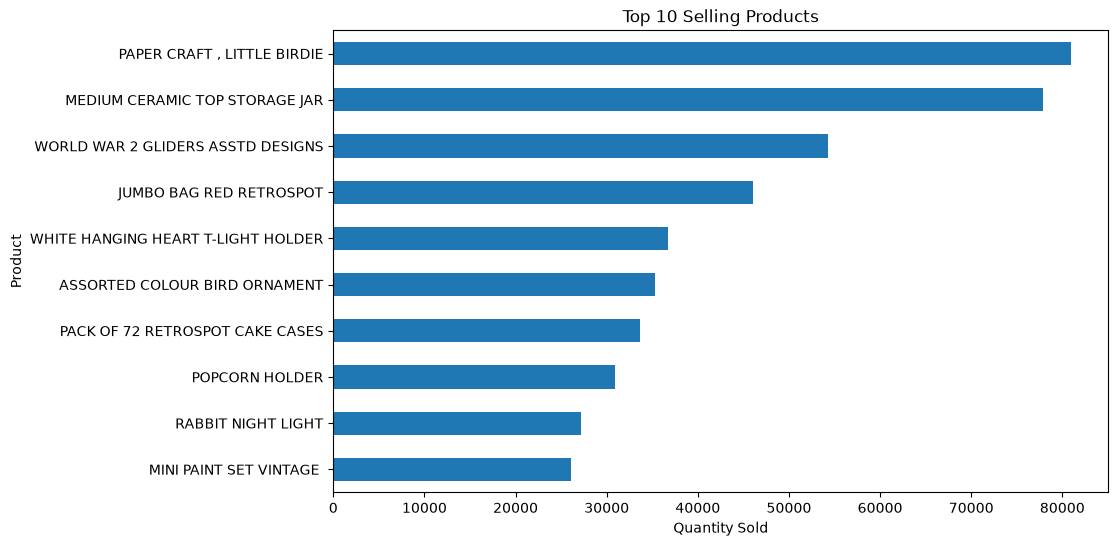

In [26]:
# ==========================================
# Top 10 Selling Products
# ==========================================

top_products = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

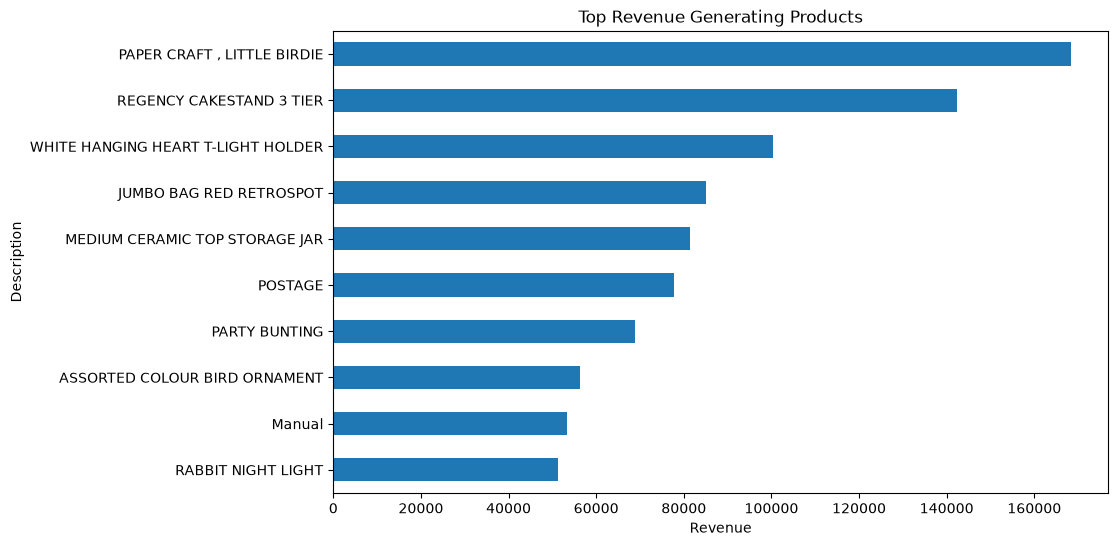

In [27]:
# ==========================================
# Top Revenue Products
# ==========================================

top_revenue_products = (
    df_clean.groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_revenue_products.sort_values().plot(kind="barh")

plt.title("Top Revenue Generating Products")
plt.xlabel("Revenue")

plt.show()

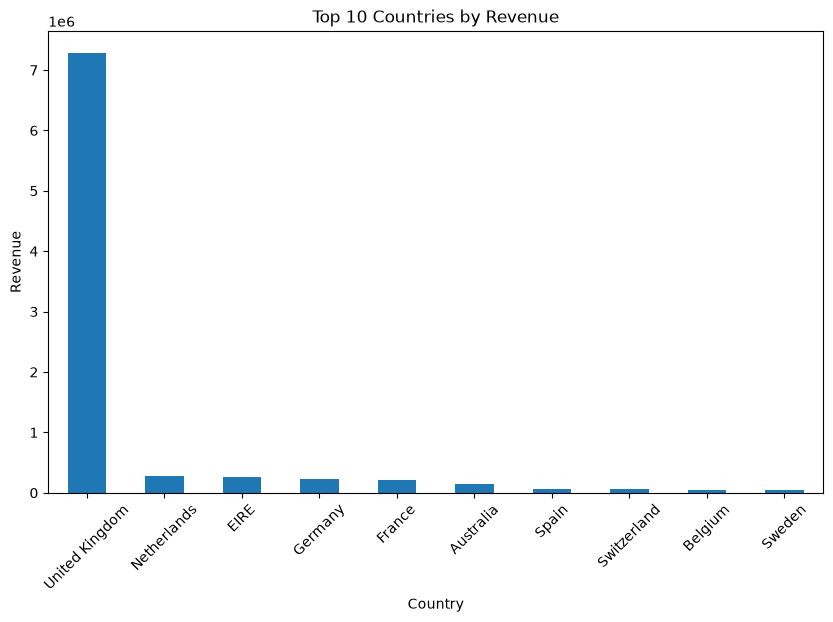

In [28]:
# ==========================================
# Revenue by Country
# ==========================================

country_sales = (
    df_clean.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [29]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

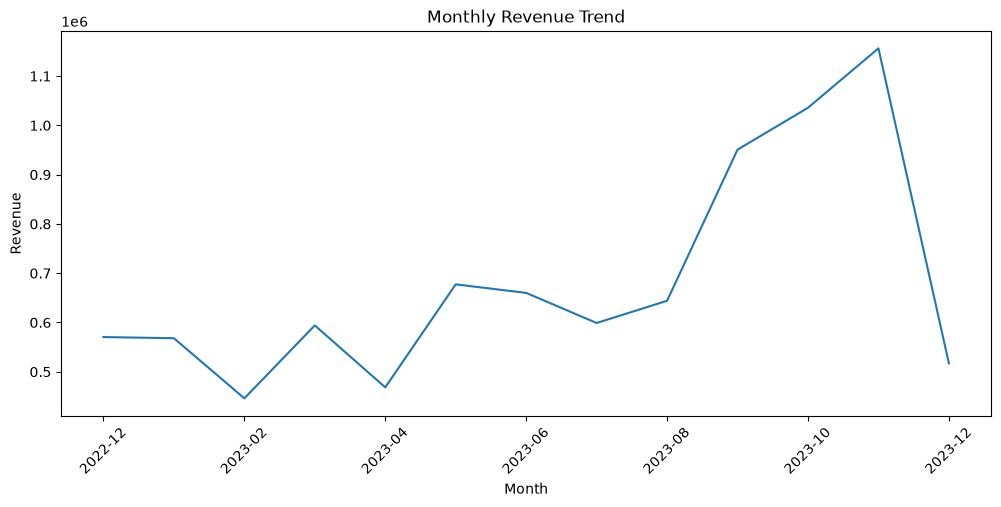

In [30]:
monthly_sales = (
    df_clean.groupby("Month")["TotalAmount"]
    .sum()
)

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

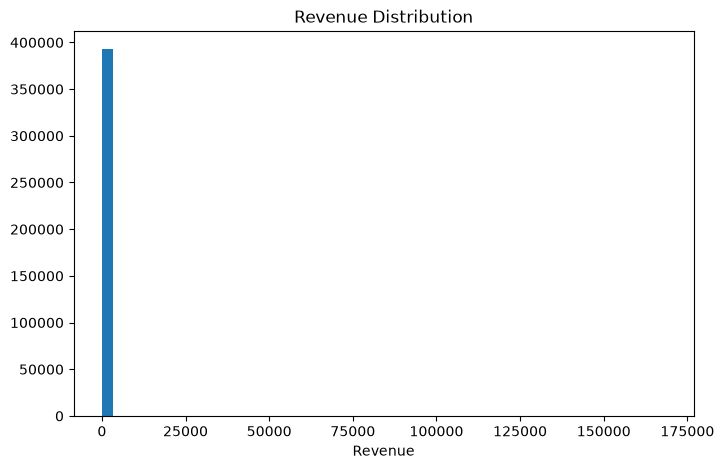

In [31]:
plt.figure(figsize=(8,5))

plt.hist(
    df_clean["TotalAmount"],
    bins=50
)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.show()

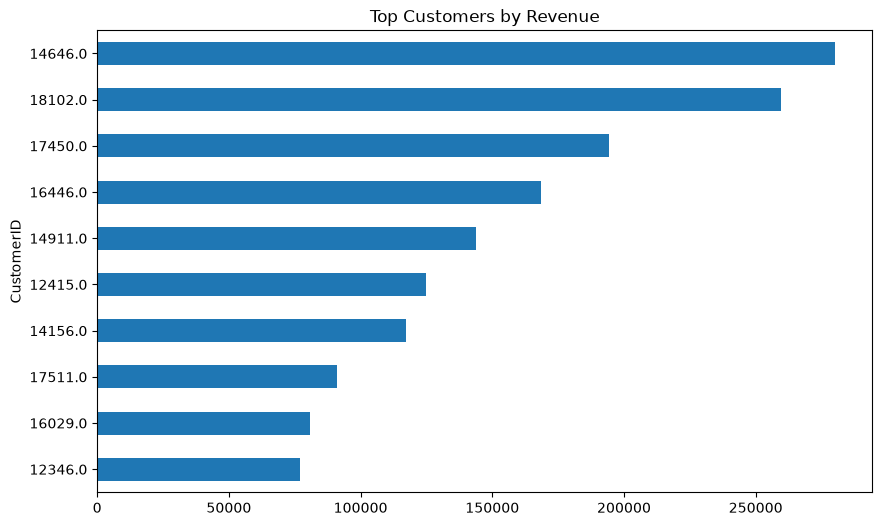

In [32]:
top_customers = (
    df_clean.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top Customers by Revenue")

plt.show()

In [33]:
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

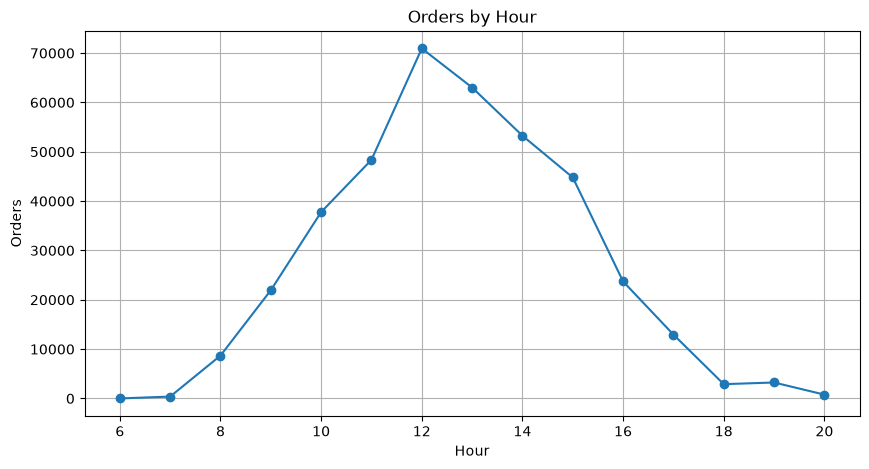

In [34]:
hourly_orders = (
    df_clean.groupby("Hour")["InvoiceNo"]
    .count()
)

plt.figure(figsize=(10,5))

hourly_orders.plot(marker="o")

plt.title("Orders by Hour")

plt.xlabel("Hour")

plt.ylabel("Orders")

plt.grid()

plt.show()

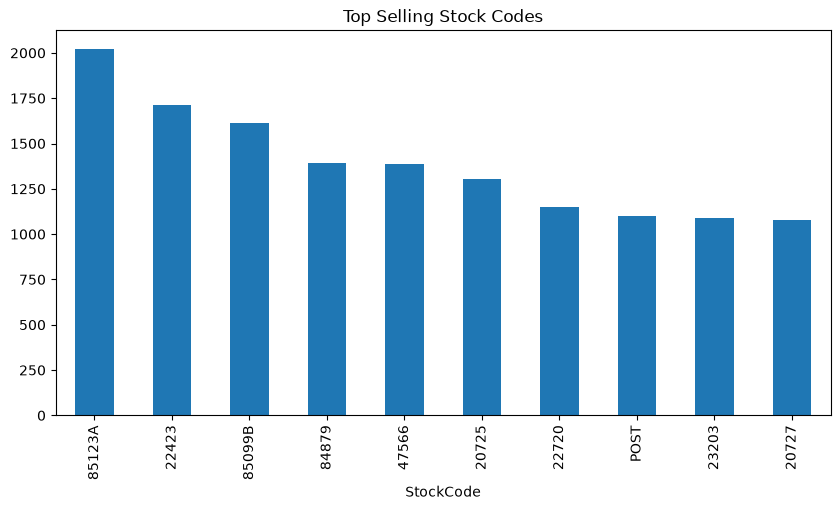

In [35]:
top_stock = (
    df_clean["StockCode"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

top_stock.plot(kind="bar")

plt.title("Top Selling Stock Codes")

plt.show()

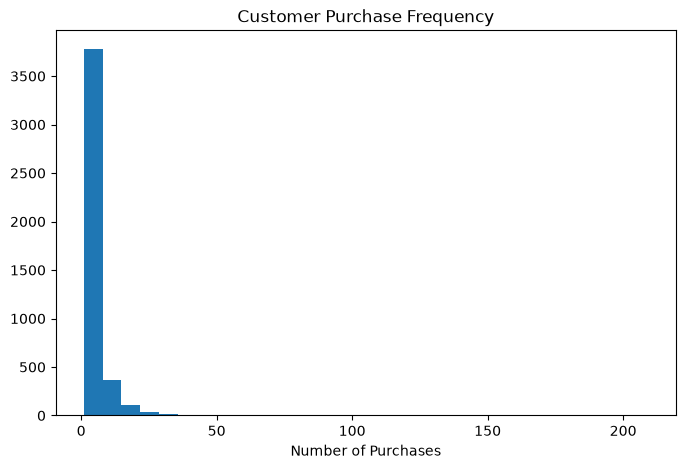

In [36]:
customer_purchase = (
    df_clean.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

plt.figure(figsize=(8,5))

plt.hist(customer_purchase, bins=30)

plt.title("Customer Purchase Frequency")

plt.xlabel("Number of Purchases")

plt.show()

In [37]:
print(pd.__version__)

3.0.3


# Customer Segmentation using RFM Analysis

In [38]:
# ==========================================
# Create Snapshot Date
# ==========================================

snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2023-12-10 12:50:00


In [39]:
# ==========================================
# Create RFM Table
# ==========================================

rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [40]:
print("RFM Shape:", rfm.shape)

RFM Shape: (4338, 3)


In [41]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [42]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

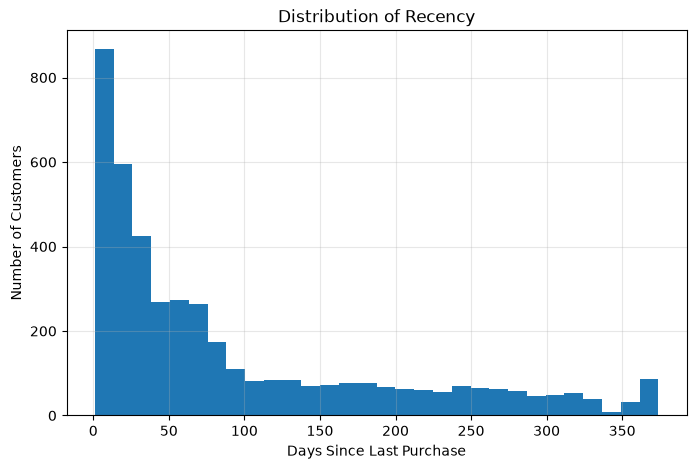

In [43]:
plt.figure(figsize=(8,5))
plt.hist(rfm["Recency"], bins=30)
plt.title("Distribution of Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.grid(alpha=0.3)
plt.show()

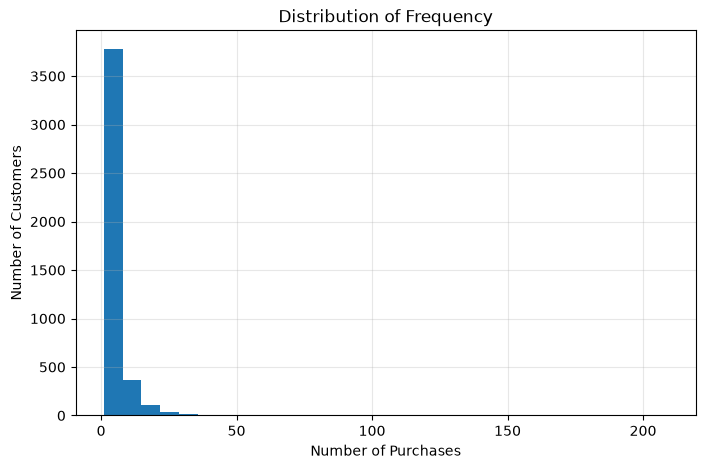

In [44]:
plt.figure(figsize=(8,5))
plt.hist(rfm["Frequency"], bins=30)
plt.title("Distribution of Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.grid(alpha=0.3)
plt.show()

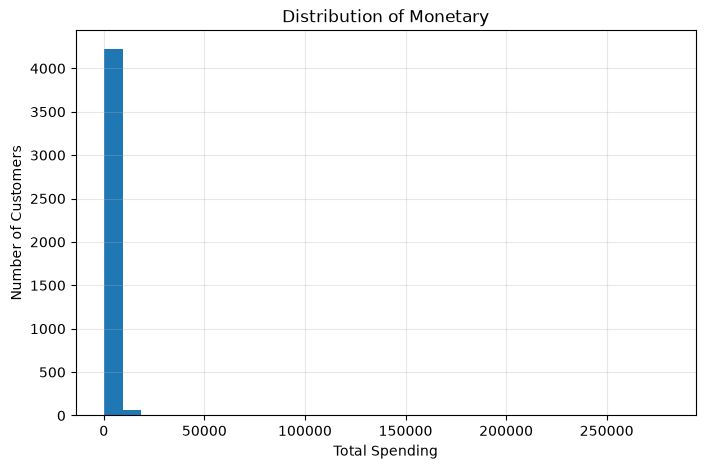

In [45]:
plt.figure(figsize=(8,5))
plt.hist(rfm["Monetary"], bins=30)
plt.title("Distribution of Monetary")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.grid(alpha=0.3)
plt.show()

# Feature Scaling and Customer Segmentation

In [46]:
# ==========================================
# Standardize RFM Features
# ==========================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print("Shape of Scaled Data:", rfm_scaled.shape)

Shape of Scaled Data: (4338, 3)


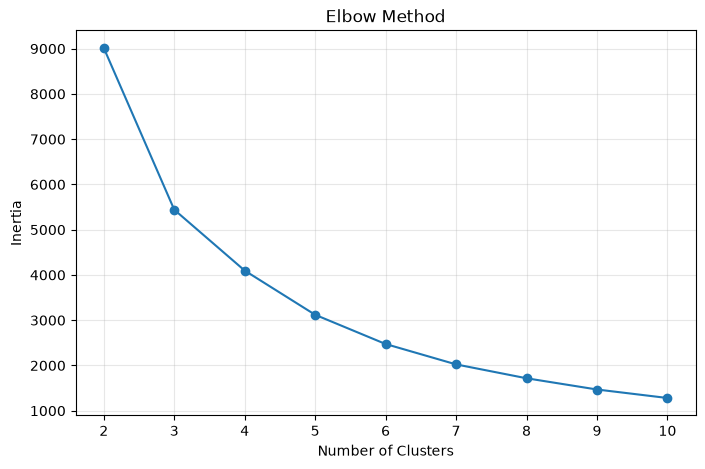

In [47]:
# ==========================================
# Elbow Method
# ==========================================

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(alpha=0.3)
plt.show()

In [48]:
# ==========================================
# Silhouette Score
# ==========================================

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    print(f"{k} Clusters : {score:.3f}")

2 Clusters : 0.896
3 Clusters : 0.594
4 Clusters : 0.616
5 Clusters : 0.617
6 Clusters : 0.598
7 Clusters : 0.517
8 Clusters : 0.486
9 Clusters : 0.478
10 Clusters : 0.479


In [49]:
# ==========================================
# Train Final K-Means Model
# ==========================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Model trained successfully!")

Model trained successfully!


In [50]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    3048
1    1063
2       8
3     213
4       6
Name: count, dtype: int64

In [51]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.92,3.65,1333.13
1,248.47,1.55,478.65
2,6.50,120.50,55099.49
3,15.67,21.29,12813.94
4,7.67,42.83,190808.54


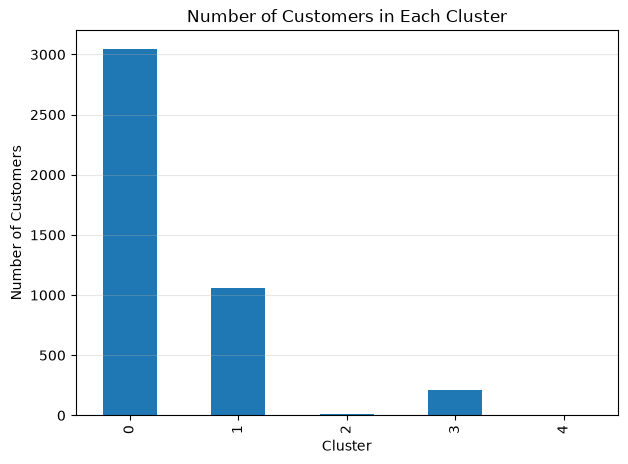

In [52]:
plt.figure(figsize=(7,5))

rfm["Cluster"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.show()

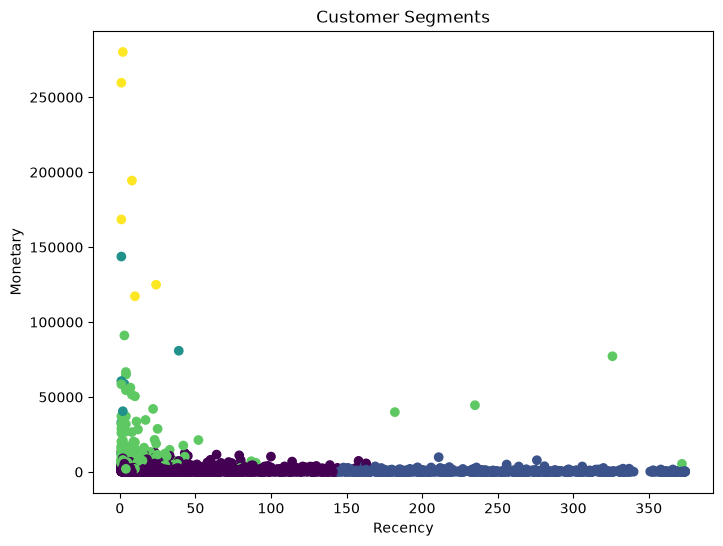

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.title("Customer Segments")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()

In [54]:
# ==========================================
# Assign Business Labels
# ==========================================

cluster_labels = {
    0: "Regular Customers",
    1: "At Risk Customers",
    2: "VIP Customers",
    3: "Loyal Customers",
    4: "Premium Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_labels)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,At Risk Customers


In [55]:
rfm["Segment"].value_counts()

Segment
Regular Customers    3048
At Risk Customers    1063
Loyal Customers       213
VIP Customers           8
Premium Customers       6
Name: count, dtype: int64

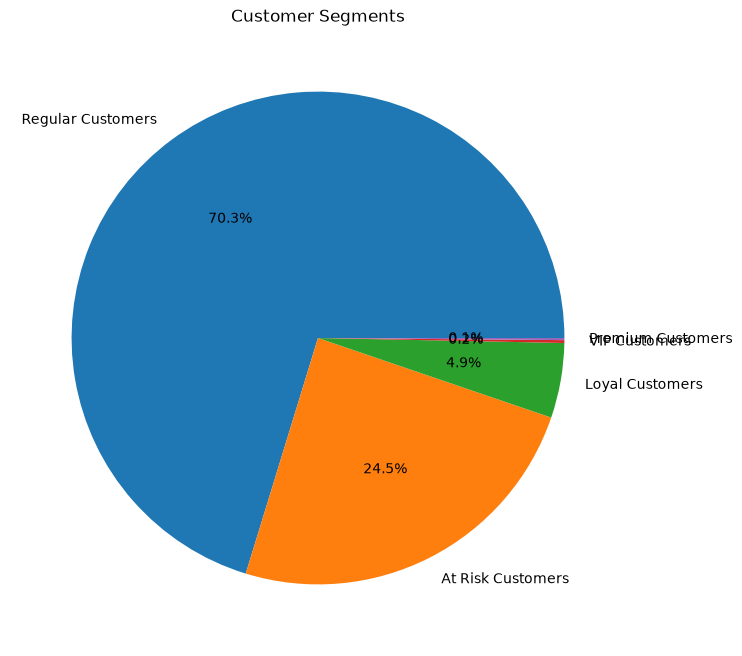

In [56]:
plt.figure(figsize=(8,8))

rfm["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Segments")

plt.ylabel("")

plt.show()

In [57]:
df_segment = df_clean.merge(
    rfm[["Segment"]],
    left_on="CustomerID",
    right_index=True
)

In [58]:
segment_revenue = (
    df_segment.groupby("Segment")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Regular Customers    4063389.103
Loyal Customers      2729369.560
Premium Customers    1144851.220
At Risk Customers     508803.081
VIP Customers         440795.930
Name: TotalAmount, dtype: float64

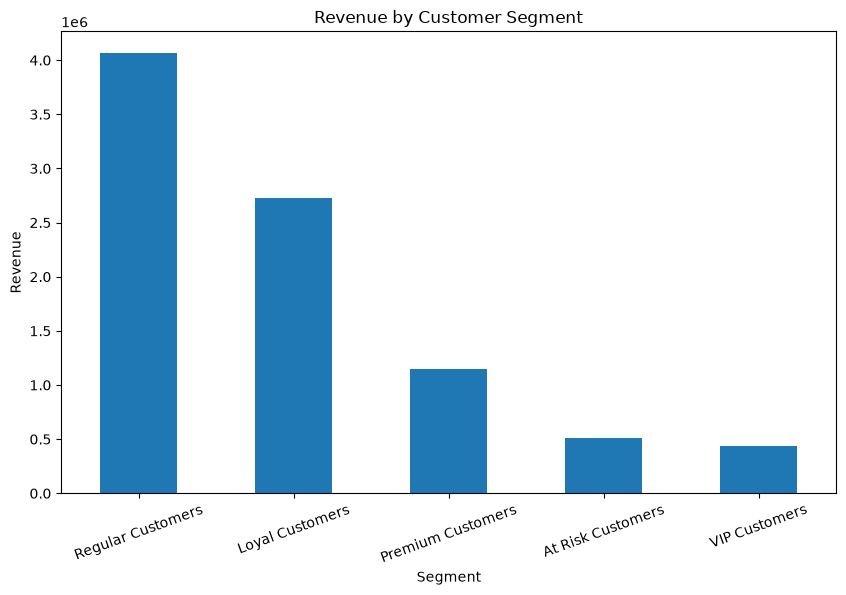

In [59]:
plt.figure(figsize=(10,6))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")

plt.xlabel("Segment")

plt.ylabel("Revenue")

plt.xticks(rotation=20)

plt.show()

In [60]:
customer_product = df_clean.pivot_table(
    index="CustomerID",
    columns="StockCode",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

customer_product.shape

(4338, 3665)

In [61]:
similarity = cosine_similarity(customer_product.T)

In [65]:
similarity_df = pd.DataFrame(
    similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

print(similarity_df.shape)

(3665, 3665)


In [62]:
def recommend_products(product_code, top_n=5):

    similar_products = similarity_df[product_code].sort_values(
        ascending=False
    )[1:top_n+1]

    return similar_products

In [63]:
customer_product.columns[:20]

Index(['10002', '10080', '10120', '10123C', '10124A', '10124G', '10125',
       '10133', '10135', '11001', '15030', '15034', '15036', '15039', '15044A',
       '15044B', '15044C', '15044D', '15056BL', '15056N'],
      dtype='str', name='StockCode')

In [66]:
recommend_products("10002")

StockCode
10125     0.853895
23224     0.713423
23222     0.699006
85014A    0.626153
20682     0.597314
Name: 10002, dtype: float64

In [67]:
# ==========================================
# Save Machine Learning Models
# ==========================================

joblib.dump(kmeans, "kmeans_model.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(similarity_df, "similarity.pkl")

joblib.dump(rfm, "rfm_data.pkl")

print("✅ All models saved successfully!")

✅ All models saved successfully!
